In [44]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import os

os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k.csv',
 'placement_dataset (1).csv',
 'placement_predict_50k_adjusted.csv',
 'placement_predict_50k_adjusted.gsheet',
 'age_insurance.csv',
 'indexData.csv']

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
df = pd.read_csv(
    '/content/drive/MyDrive/Colab/indexData.csv'
)

print(df.head())
print("\nDataset Shape:", df.shape)

  Index        Date        Open        High         Low       Close  \
0   NYA  1965-12-31  528.690002  528.690002  528.690002  528.690002   
1   NYA  1966-01-03  527.210022  527.210022  527.210022  527.210022   
2   NYA  1966-01-04  527.840027  527.840027  527.840027  527.840027   
3   NYA  1966-01-05  531.119995  531.119995  531.119995  531.119995   
4   NYA  1966-01-06  532.070007  532.070007  532.070007  532.070007   

    Adj Close  Volume  
0  528.690002     0.0  
1  527.210022     0.0  
2  527.840027     0.0  
3  531.119995     0.0  
4  532.070007     0.0  

Dataset Shape: (112457, 8)


In [60]:
df = df.dropna(
    subset=["Open", "High", "Low", "Close", "Volume"]
)

df["Next_Close"] = df["Close"].shift(-1)

df = df.dropna()

feature_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

X = df[feature_cols].values

y = df["Next_Close"].values.reshape(-1, 1)

print("Features:", X.shape)
print("Target:", y.shape)

Features: (110252, 5)
Target: (110252, 1)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 88201
Testing samples: 22051


In [62]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

X_train_b = np.c_[
    np.ones((X_train.shape[0], 1)),
    X_train
]

X_test_b = np.c_[
    np.ones((X_test.shape[0], 1)),
    X_test
]

print("Training shape:", X_train_b.shape)
print("Testing shape:", X_test_b.shape)

Training shape: (88201, 6)
Testing shape: (22051, 6)


In [63]:
def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape

    theta = np.zeros((n, 1))

    losses = []

    for i in range(n_iters):

        y_pred = X @ theta

        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)

        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

In [64]:
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    lr=0.01,
    n_iters=1000
)

Iteration    0 | Loss: 70044310.7979
Iteration  100 | Loss: 4011974.7914
Iteration  200 | Loss: 578447.3052
Iteration  300 | Loss: 119819.0426
Iteration  400 | Loss: 58362.7260
Iteration  500 | Loss: 50127.2318
Iteration  600 | Loss: 49023.4087
Iteration  700 | Loss: 48875.2485
Iteration  800 | Loss: 48855.1507
Iteration  900 | Loss: 48852.2141


In [65]:
y_pred = X_test_b @ theta

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nFinal weights:")
print(theta.ravel())

print(f"\nTest MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")


Final weights:
[7.66950283e+03 2.24865113e+03 2.25212780e+03 2.25224242e+03
 2.25620353e+03 7.33957711e-01]

Test MSE: 69289.2984
Test R^2: 0.9991


In [66]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()

sk_model.fit(
    X_train,
    y_train
)

sk_pred = sk_model.predict(X_test)

print(
    f"sklearn LinearRegression R^2: "
    f"{r2_score(y_test, sk_pred):.4f}"
)

sklearn LinearRegression R^2: 0.9992


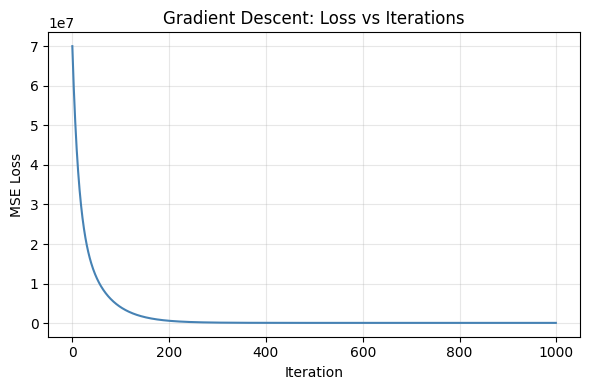

In [67]:
plt.figure(figsize=(6, 4))

plt.plot(
    range(len(losses)),
    losses,
    color="steelblue"
)

plt.title("Gradient Descent: Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

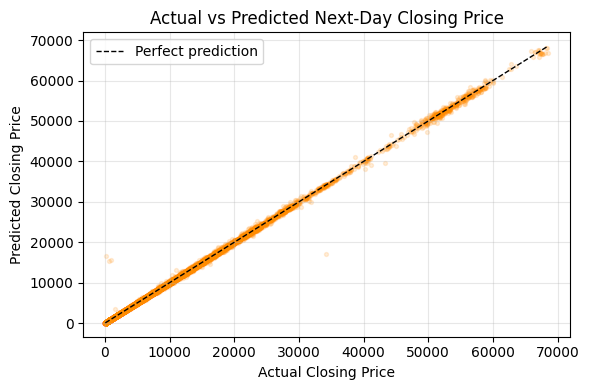

In [68]:
plt.figure(figsize=(6, 4))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.15,
    s=8,
    color="darkorange"
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

plt.title("Actual vs Predicted Next-Day Closing Price")
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

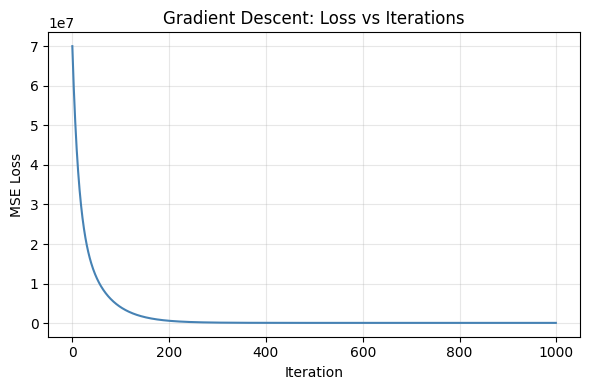

Saved to Google Drive → Colab → index_gradient_descent.png


In [69]:
plt.figure(figsize=(6, 4))

plt.plot(
    range(len(losses)),
    losses,
    color="steelblue"
)

plt.title("Gradient Descent: Loss vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '/content/drive/MyDrive/Colab/index_gradient_descent.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Saved to Google Drive → Colab → index_gradient_descent.png")